<a href="https://colab.research.google.com/github/AhmedButtar7/AI-ML-internship-DevelopersHub/blob/main/Phase_2/Task_2/Developers_Hub_Phase_2_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Scikit-learn components
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Model export
import joblib

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
url = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (7043, 21)

First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic data exploration
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget variable distribution:")
print(df['Churn'].value_counts(normalize=True))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [ ]:
def clean_data(df):
    """Clean and prepare the dataset"""
    # Make a copy
    df_clean = df.copy()

    # Drop customerID (not useful for prediction)
    df_clean = df_clean.drop('customerID', axis=1)

    # Convert TotalCharges to numeric (it's currently object/string)
    df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

    # Convert target variable to binary
    df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

    # Fill missing TotalCharges with median
    df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

    return df_clean

# Clean the data
df_clean = clean_data(df)
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Separate features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Numeric pipeline: Impute missing values (if any) + Scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle any remaining missing values
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute + One-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Create pipelines with different models
pipelines = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),

    'RandomForest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ])
}

print("Complete ML pipelines created!")

Complete ML pipelines created!


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Training set size: (5634, 19)
Test set size: (1409, 19)

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [ ]:
# Train baseline models
baseline_results = {}

for name, pipeline in pipelines.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calculate metrics
    auc = roc_auc_score(y_test, y_pred_proba)

    # Store results
    baseline_results[name] = {
        'pipeline': pipeline,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'auc': auc
    }

    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Training LogisticRegression...

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8420

Confusion Matrix:
[[926 109]
 [165 209]]

Training RandomForest...

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC-AUC Score: 0.8246

Confusion Matrix:
[[923 112]
 [190 184]]


In [ ]:
# OPTIMIZED - Much Faster Hyperparameter Grids

param_grids = {
    'LogisticRegression': {
        'classifier__C': [0.1, 1, 10],  # Reduced from 5 to 3 options
        'classifier__penalty': ['l2'],   # l2 is default and works well
        'classifier__solver': ['lbfgs']  # lbfgs handles l2 penalty efficiently
    },

    'RandomForest': {
        'classifier__n_estimators': [100, 200],  # Reduced from 3 to 2
        'classifier__max_depth': [10, 20],       # Removed None (which causes deep trees)
        'classifier__min_samples_split': [5, 10], # Reduced from 3 to 2
        'classifier__min_samples_leaf': [1, 4]    # Kept 2 options
        # Removed class_weight for faster training
    }
}

In [ ]:
# Perform GridSearchCV for each model
tuned_results = {}
best_models = {}

for name, pipeline in pipelines.items():
    print(f"\n{'='*50}")
    print(f"Performing GridSearchCV for {name}...")
    print(f"{'='*50}")

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    tuned_results[name] = grid_search
    best_models[name] = grid_search.best_estimator_

    print(f"Finished GridSearchCV for {name}.")
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation ROC-AUC: {grid_search.best_score_:.4f}")


Performing GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Finished GridSearchCV for LogisticRegression.
Best parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best cross-validation ROC-AUC: 0.8458

Performing GridSearchCV for RandomForest...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Finished GridSearchCV for RandomForest.
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best cross-validation ROC-AUC: 0.8449


In [ ]:
# Re-run the comparison to include tuned model results

comparison_data = []

for name in pipelines.keys():
    # Baseline performance
    baseline_auc = baseline_results[name]['auc']

    # Tuned performance
    tuned_cv_auc = tuned_results[name].best_score_
    tuned_test_auc = roc_auc_score(y_test, tuned_results[name].predict_proba(X_test)[:, 1])

    comparison_data.append({
        'Model': name,
        'Baseline Test AUC': baseline_auc,
        'Tuned CV AUC (5-fold)': tuned_cv_auc,
        'Tuned Test AUC': tuned_test_auc,
        'Improvement': tuned_test_auc - baseline_auc
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Select the best model
best_model_name = comparison_df.loc[comparison_df['Tuned Test AUC'].idxmax(), 'Model']
final_model = best_models[best_model_name]

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Test ROC-AUC: {comparison_df.loc[comparison_df['Model']==best_model_name, 'Tuned Test AUC'].values[0]:.4f}")


MODEL PERFORMANCE COMPARISON
             Model  Baseline Test AUC  Tuned CV AUC (5-fold)  Tuned Test AUC  Improvement
LogisticRegression           0.842006               0.845849        0.841166    -0.000840
      RandomForest           0.824645               0.844938        0.843349     0.018704

🏆 BEST MODEL: RandomForest
Test ROC-AUC: 0.8433



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
                       feature  importance
                        tenure    0.198460
                  TotalCharges    0.149513
                MonthlyCharges    0.105098
   InternetService_Fiber optic    0.079074
PaymentMethod_Electronic check    0.067956
             Contract_Two year    0.067895
             Contract_One year    0.039701
            OnlineSecurity_Yes    0.035731
               TechSupport_Yes    0.022362
          PaperlessBilling_Yes    0.020614

Feature importance plot saved as 'feature_importance.png'


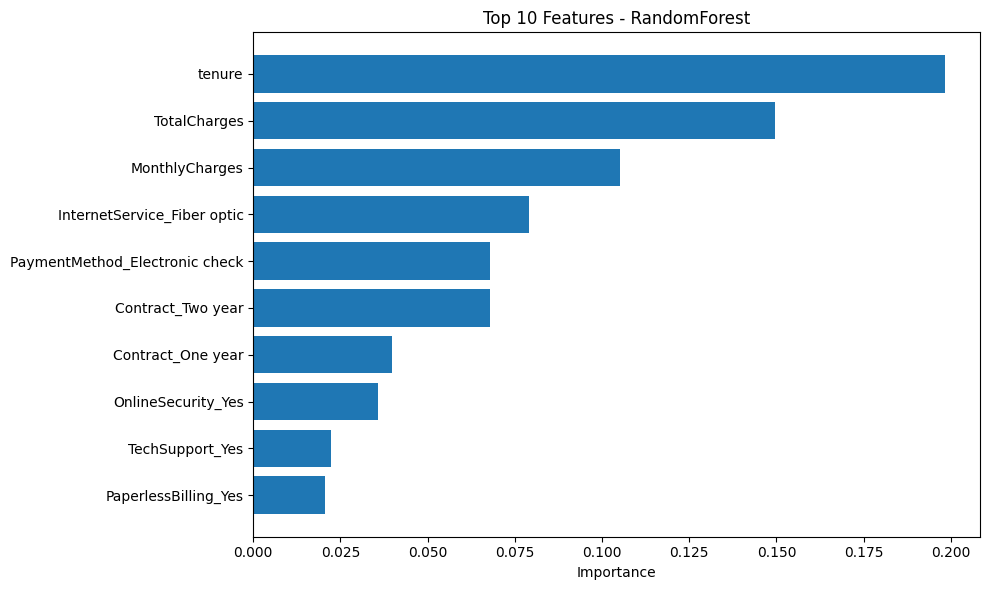

In [ ]:
# Re-run the feature importance analysis now that RandomForest is the best model
# If the best model is Random Forest, analyze feature importance
if 'final_model' in locals() and best_model_name == 'RandomForest':
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)

    # Get feature names after preprocessing
    # Get the onehot encoder from the pipeline
    preprocessor_fitted = final_model.named_steps['preprocessor']

    # Get categorical feature names
    cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
    cat_features = cat_encoder.get_feature_names_out(categorical_features)

    # Combine feature names
    all_features = numeric_features + list(cat_features)

    # Get feature importances
    feature_importances = final_model.named_steps['classifier'].feature_importances_

    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': all_features,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)

    # Display top 10 features
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    # Optional: Plot feature importance
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(10)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    print("\nFeature importance plot saved as 'feature_importance.png'")
elif 'final_model' in locals():
    print(f"\nFeature importance is not applicable or not implemented for {best_model_name}.")
else:
    print("\nNo final model selected for feature importance analysis.")

In [ ]:
# Export the complete pipeline using joblib
model_filename = f'churn_prediction_pipeline_{best_model_name}.joblib'

# Save the model
joblib.dump(final_model, model_filename)
print(f"\n{'='*60}")
print(f"✅ Model exported successfully!")
print(f"{'='*60}")
print(f"File saved as: {model_filename}")
print(f"Model type: {best_model_name}")
print(f"File size: {joblib.load(model_filename).__sizeof__() / 1024:.2f} KB")

# Also save metadata
import json
metadata = {
    'model_name': best_model_name,
    'test_roc_auc': float(comparison_df.loc[comparison_df['Model']==best_model_name, 'Tuned Test AUC'].values[0]),
    'features_count': len(all_features) if 'all_features' in dir() else X.shape[1],
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X.shape[1],
    'n_samples': len(X)
}

metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Metadata saved as: {metadata_filename}")


✅ Model exported successfully!
File saved as: churn_prediction_pipeline_RandomForest.joblib
Model type: RandomForest
File size: 0.02 KB
Metadata saved as: model_metadata.json


In [ ]:
# Example of loading and using the exported pipeline
print("\n" + "="*60)
print("DEMONSTRATING MODEL REUSABILITY")
print("="*60)

# Load the pipeline
loaded_pipeline = joblib.load(model_filename)

# Example prediction on new sample
sample_data = X_test.iloc[0:1]  # First test sample
expected_churn = y_test.iloc[0]

# Make prediction
prediction = loaded_pipeline.predict(sample_data)
prediction_proba = loaded_pipeline.predict_proba(sample_data)[0]

print(f"\nExample Prediction:")
print(f"Customer features shape: {sample_data.shape}")
print(f"Expected churn: {'Yes' if expected_churn == 1 else 'No'}")
print(f"Predicted churn: {'Yes' if prediction[0] == 1 else 'No'}")
print(f"Prediction probabilities: [No: {prediction_proba[0]:.4f}, Yes: {prediction_proba[1]:.4f}]")

# Batch prediction example
print(f"\nBatch prediction on 5 customers:")
batch_samples = X_test.iloc[0:5]
batch_predictions = loaded_pipeline.predict(batch_samples)
batch_probabilities = loaded_pipeline.predict_proba(batch_samples)[:, 1]

for i, (pred, prob) in enumerate(zip(batch_predictions, batch_probabilities)):
    status = "Churn Risk" if pred == 1 else "Safe"
    print(f"Customer {i+1}: {status} (Probability: {prob:.2%})")


DEMONSTRATING MODEL REUSABILITY

Example Prediction:
Customer features shape: (1, 19)
Expected churn: No
Predicted churn: No
Prediction probabilities: [No: 0.9829, Yes: 0.0171]

Batch prediction on 5 customers:
Customer 1: Safe (Probability: 1.71%)
Customer 2: Churn Risk (Probability: 72.65%)
Customer 3: Safe (Probability: 9.88%)
Customer 4: Safe (Probability: 38.82%)
Customer 5: Safe (Probability: 2.07%)


In [ ]:
def predict_churn(pipeline, customer_data, return_probabilities=True):
    """
    Production-ready prediction function

    Parameters:
    -----------
    pipeline : fitted sklearn Pipeline
        The trained pipeline
    customer_data : pandas DataFrame
        Customer data with same features as training
    return_probabilities : bool
        Whether to return probability scores

    Returns:
    --------
    dict : Prediction results
    """
    # Validate input
    required_columns = X.columns.tolist()
    missing_cols = set(required_columns) - set(customer_data.columns)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Make predictions
    predictions = pipeline.predict(customer_data)
    probabilities = pipeline.predict_proba(customer_data)

    # Format results
    results = {
        'predictions': ['Churn' if pred == 1 else 'No Churn' for pred in predictions],
        'predictions_binary': predictions.tolist(),
    }

    if return_probabilities:
        results['probabilities'] = {
            'no_churn': probabilities[:, 0].tolist(),
            'churn': probabilities[:, 1].tolist()
        }

    return results

# Test the prediction function
print("\n" + "="*60)
print("TESTING PRODUCTION PREDICTION FUNCTION")
print("="*60)

test_sample = X_test.iloc[0:3]
results = predict_churn(loaded_pipeline, test_sample)

print("\nPrediction Results:")
for i in range(len(test_sample)):
    print(f"\nCustomer {i+1}:")
    print(f"  Prediction: {results['predictions'][i]}")
    print(f"  Churn Probability: {results['probabilities']['churn'][i]:.2%}")


TESTING PRODUCTION PREDICTION FUNCTION

Prediction Results:

Customer 1:
  Prediction: No Churn
  Churn Probability: 1.71%

Customer 2:
  Prediction: Churn
  Churn Probability: 72.65%

Customer 3:
  Prediction: No Churn
  Churn Probability: 9.88%


In [ ]:
# Create a complete production package
import os

# Create directory for production artifacts
production_dir = "churn_prediction_production"
os.makedirs(production_dir, exist_ok=True)

# Save all components
joblib.dump(final_model, f"{production_dir}/pipeline.joblib")
joblib.dump(preprocessor, f"{production_dir}/preprocessor.joblib")

# Save training metadata
training_info = {
    'features_used': X.columns.tolist(),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_mapping': {'No': 0, 'Yes': 1},
    'model_parameters': final_model.get_params(),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'class_distribution': y_train.value_counts(normalize=True).to_dict()
}

with open(f"{production_dir}/training_info.json", 'w') as f:
    json.dump(training_info, f, indent=4)

# Save requirements file
requirements = """
pandas>=1.3.0
numpy>=1.21.0
scikit-learn>=1.0.0
joblib>=1.1.0
matplotlib>=3.4.0
seaborn>=0.11.0
"""

with open(f"{production_dir}/requirements.txt", 'w') as f:
    f.write(requirements)

print(f"\n{'='*60}")
print(f"✅ Production package created in '{production_dir}/'")
print(f"{'='*60}")
print("Files saved:")
print(f"  - pipeline.joblib (trained model)")
print(f"  - preprocessor.joblib (preprocessing pipeline)")
print(f"  - training_info.json (metadata)")
print(f"  - requirements.txt (dependencies)")

# Create a README for production deployment
readme_content = f"""
# Customer Churn Prediction Model

## Model Information
- **Model Type**: {best_model_name}
- **Test ROC-AUC**: {comparison_df.loc[comparison_df['Model']==best_model_name, 'Tuned Test AUC'].values[0]:.4f}
- **Training Date**: {metadata['training_date']}
- **Features**: {len(X.columns)} features used

## Quick Start

### Load the model:
```python
import joblib
import pandas as pd

# Load pipeline
pipeline = joblib.load('pipeline.joblib')

# Make predictions
predictions = pipeline.predict(your_dataframe)
probabilities = pipeline.predict_proba(your_dataframe)

SyntaxError: incomplete input (3444314286.py, line 50)